<a href="https://colab.research.google.com/github/harishraghavhr7/smart_factory_machinery_prediction/blob/main/smart_factory_machinery_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  1000 non-null   float64
 1   vibration    1000 non-null   float64
 2   rpm          1000 non-null   int64  
 3   settings     1000 non-null   object 
 4   quality      1000 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


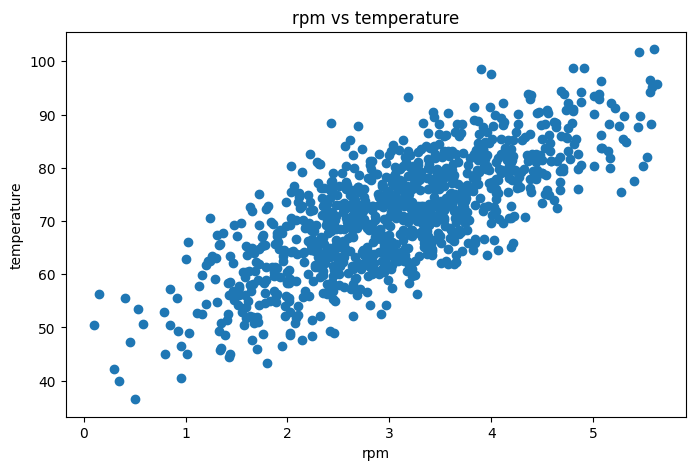

In [ ]:
import matplotlib.pyplot as plt
x=df["rpm"]
y=df["temperature"]

plt.figure(figsize=(8,5))

plt.scatter(x,y)

plt.xlabel("rpm")
plt.ylabel("temperature")
plt.title("rpm vs temperature")

plt.show()

SINGLE VARIABLE LINEAR REGRESSION


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
x=df[["rpm"]]
y=df["temperature"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)


In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# Prediction
y_pred = model.predict(x_test)

# Evaluation
print("R2 Score :", r2_score(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)


R2 Score : 0.25298649637173043
RMSE : 9.983070075285829


MULTI VARIABLE LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
x=df[["rpm","vibration"]]
y=df["temperature"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# Prediction
y_pred = model.predict(x_test)

# Evaluation
print("R2 Score :", r2_score(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)


R2 Score : 0.8199211403615879
RMSE : 4.901525419436989


the model experienced gain in accuracy by 53% from 23% to 86% the model has explained 86 % variance so only left  behind 14%

so the model shows strong linear relationship

3.SAVING MODEL WITH PICKLE AND JOBLIB

In [ ]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [ ]:
import pickle

# Save model
with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

4.one hot encoding


In [ ]:
new_df=df

new_df.drop("quality",axis=1)

,temperature,vibration,rpm,settings
0,74.96,3.05,1726,Mode_C
1,68.72,2.17,1667,Mode_A
2,56.30,3.27,818,Mode_C
3,62.10,2.95,1231,Mode_C
4,63.62,2.76,1539,Mode_A
...,...,...,...,...
995,82.33,3.00,1889,Mode_B
996,72.77,2.83,1735,Mode_B
997,68.52,2.55,2480,Mode_C
998,73.77,3.70,1174,Mode_C


In [ ]:
encoded_df = pd.get_dummies(new_df,columns=["settings"])

In [ ]:
print(encoded_df)

     temperature  vibration   rpm quality  settings_Mode_A  settings_Mode_B  \
0          74.96       3.05  1726    Pass            False            False   
1          68.72       2.17  1667    Pass             True            False   
2          56.30       3.27   818    Pass            False            False   
3          62.10       2.95  1231    Pass            False            False   
4          63.62       2.76  1539    Pass             True            False   
..           ...        ...   ...     ...              ...              ...   
995        82.33       3.00  1889    Pass            False             True   
996        72.77       2.83  1735    Pass            False             True   
997        68.52       2.55  2480    Pass            False            False   
998        73.77       3.70  1174    Pass            False            False   
999        63.55       3.96   961    Pass             True            False   

     settings_Mode_C  
0               True  
1    

In [ ]:
encoded_df.drop("quality",axis=1)

,temperature,vibration,rpm,settings_Mode_A,settings_Mode_B,settings_Mode_C
0,74.96,3.05,1726,False,False,True
1,68.72,2.17,1667,True,False,False
2,56.30,3.27,818,False,False,True
3,62.10,2.95,1231,False,False,True
4,63.62,2.76,1539,True,False,False
...,...,...,...,...,...,...
995,82.33,3.00,1889,False,True,False
996,72.77,2.83,1735,False,True,False
997,68.52,2.55,2480,False,False,True
998,73.77,3.70,1174,False,False,True


In [ ]:
encoded_df_numeric = encoded_df.drop(["settings_Mode_C","quality"], axis=1)
x = encoded_df_numeric.drop("temperature", axis=1)

# Target column
y = encoded_df_numeric["temperature"]

In [ ]:
print(x)

     vibration   rpm  settings_Mode_A  settings_Mode_B
0         3.05  1726            False            False
1         2.17  1667             True            False
2         3.27   818            False            False
3         2.95  1231            False            False
4         2.76  1539             True            False
..         ...   ...              ...              ...
995       3.00  1889            False             True
996       2.83  1735            False             True
997       2.55  2480            False            False
998       3.70  1174            False            False
999       3.96   961             True            False

[1000 rows x 4 columns]


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
model=LinearRegression()
model.fit(x_train,y_train)
# Prediction
y_pred = model.predict(x_test)

# Evaluation
print("R2 Score :", r2_score(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred) ** 0.5)


R2 Score : 0.8149402481022892
RMSE : 4.968849939429663


6.logistic regression

In [ ]:
x=encoded_df.drop(["quality","settings_Mode_C"],axis=1)
y=encoded_df["quality"]

In [ ]:
x

,temperature,vibration,rpm,settings_Mode_A,settings_Mode_B
0,74.96,3.05,1726,False,False
1,68.72,2.17,1667,True,False
2,56.30,3.27,818,False,False
3,62.10,2.95,1231,False,False
4,63.62,2.76,1539,True,False
...,...,...,...,...,...
995,82.33,3.00,1889,False,True
996,72.77,2.83,1735,False,True
997,68.52,2.55,2480,False,False
998,73.77,3.70,1174,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression()

# Training
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.96

Classification Report:

              precision    recall  f1-score   support

        Fail       0.76      0.96      0.85        23
        Pass       0.99      0.96      0.98       177

    accuracy                           0.96       200
   macro avg       0.88      0.96      0.91       200
weighted avg       0.97      0.96      0.96       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
